# Retail Sales - Exploratory Data Analysis & KPI Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"C:\Users\shahul\Downloads\royal_store_cleaned")
df['Date'] = pd.to_datetime(df['Date'])
df_sales = df[df['IsReturn']== False].copy()
df_sales.head()

,Bill.NO,Date,Product Name,Qty,Rate,Amount,Total,IsReturn,Year,Month,Day,Weekday,Sales_Category
0,1,2025-04-01,GOLDWINNER 200ML,1.0,35.0,35.0,35.0,False,2025,4,1,Tuesday,Retail sales
2,2,2025-04-01,CARRY BAG 13*16 WHITE PAK,1.0,35.0,35.0,35.0,False,2025,4,1,Tuesday,Retail sales
4,3,2025-04-01,GULAS JAGGERY 500GM,1.0,47.0,47.0,47.0,False,2025,4,1,Tuesday,Retail sales
5,4,2025-04-01,KASTHURI MANJAL 50G,1.0,23.0,23.0,23.0,False,2025,4,1,Tuesday,Retail sales
6,4,2025-04-01,NATURE POWER LIME SOAP 125GM,1.0,44.0,44.0,44.0,False,2025,4,1,Tuesday,Retail sales


# 1. Business Overview

In [9]:
print(f"Shape : {df.shape}")
print(f"Date Range : {df['Date'].min()} -> {df['Date'].max()}")
print(f"Total Bills: {df['Bill.NO'].nunique()}")
print(f"Total Products:{df['Product Name'].nunique()}")
print(f"Total Revenue : {df['Total'].sum():,.0f}")
print(f"Avg Bill Value : {df_sales.groupby("Bill.NO")["Total"].sum().mean():,.0f}")
print(f"Return Rate :{df["IsReturn"].mean()*100:.2f}%")


Shape : (130553, 13)
Date Range : 2025-04-01 00:00:00 -> 2025-07-08 00:00:00
Total Bills: 39204
Total Products:4614
Total Revenue : 7,853,902
Avg Bill Value : 201
Return Rate :0.09%


# 2. Variable Distribution

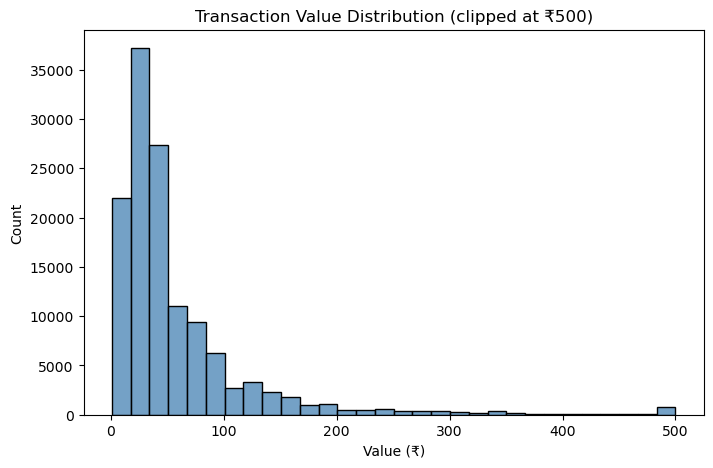

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sales['Total'].clip(upper=500), bins=30, color='steelblue')
plt.title('Transaction Value Distribution (clipped at ₹500)')
plt.xlabel('Value (₹)')
plt.ylabel('Count')
plt.show()

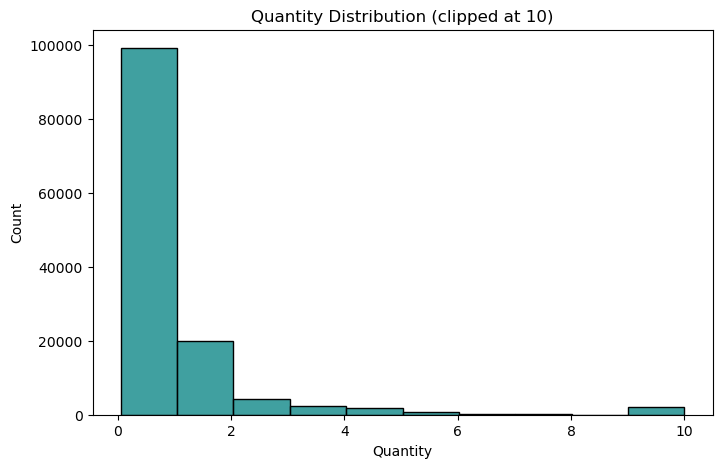

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sales['Qty'].clip(upper=10), bins=10, color='teal')
plt.title('Quantity Distribution (clipped at 10)')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

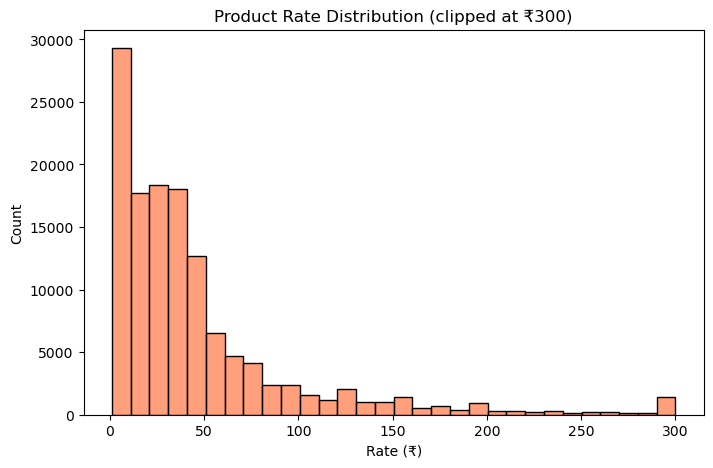

In [13]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sales['Rate'].clip(upper=300), bins=30, color='coral')
plt.title('Product Rate Distribution (clipped at ₹300)')
plt.xlabel('Rate (₹)')
plt.ylabel('Count')
plt.show()

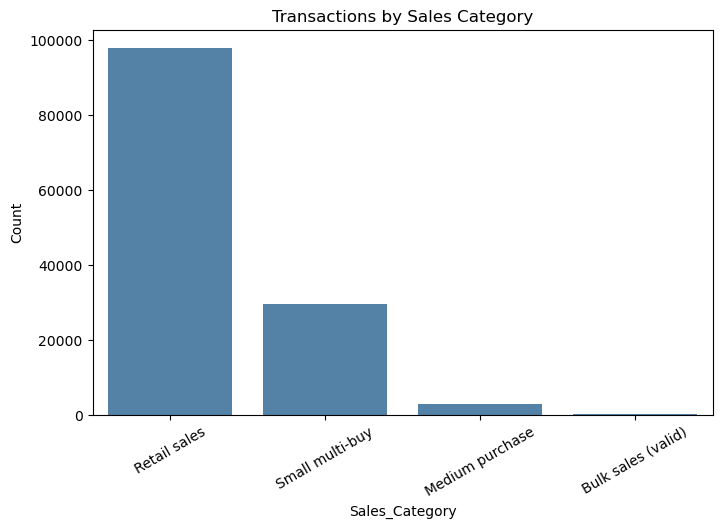

In [15]:
cat_counts = df_sales['Sales_Category'].value_counts().reset_index()
cat_counts.columns = ['Sales_Category', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(data=cat_counts, x='Sales_Category', y='Count', color='steelblue')
plt.title('Transactions by Sales Category')
plt.xticks(rotation=30)
plt.show()

# 3. Daily Sales

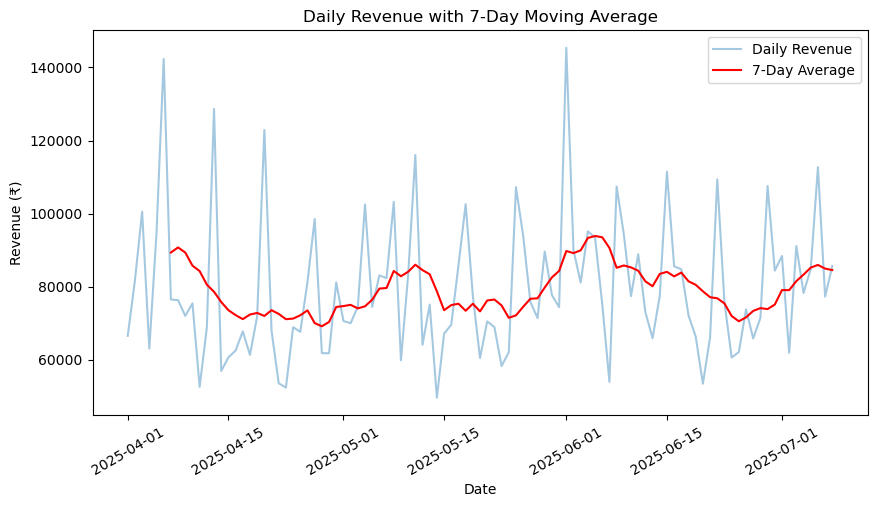

In [17]:
daily = df_sales.groupby('Date').agg(
    Revenue=('Total', 'sum'),
    Bills=('Bill.NO', 'nunique'),
    Items_sold=('Qty', 'sum')
).reset_index()
daily['Revenue_7MA'] = daily['Revenue'].rolling(7).mean()

plt.figure(figsize=(10, 5))
plt.plot(daily['Date'], daily['Revenue'], alpha=0.4, label='Daily Revenue')
plt.plot(daily['Date'], daily['Revenue_7MA'], color='red', label='7-Day Average')
plt.title('Daily Revenue with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.xticks(rotation=30)
plt.show()

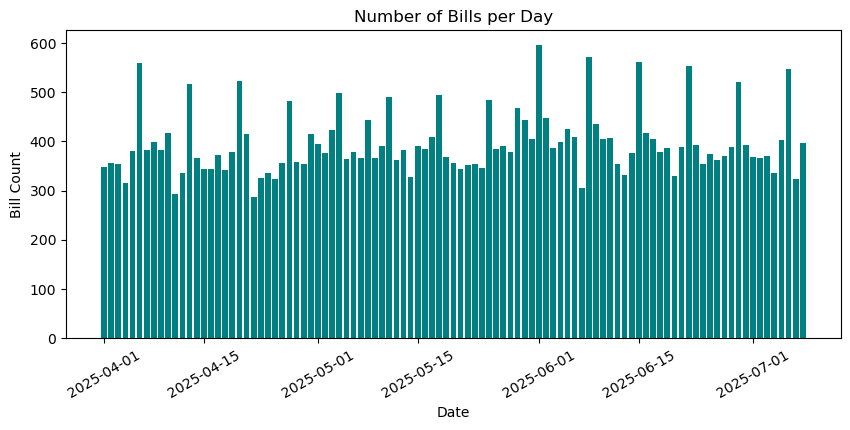

In [19]:
plt.figure(figsize=(10, 4))
plt.bar(daily['Date'], daily['Bills'], color='teal')
plt.title('Number of Bills per Day')
plt.xlabel('Date')
plt.ylabel('Bill Count')
plt.xticks(rotation=30)
plt.show()

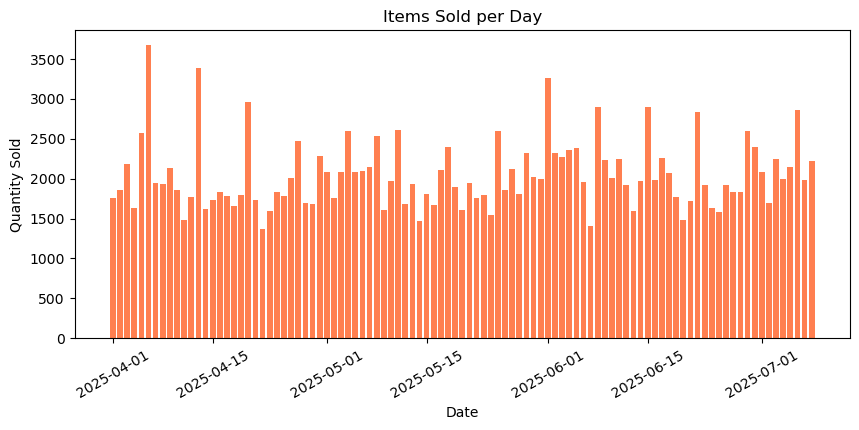

In [20]:
plt.figure(figsize=(10, 4))
plt.bar(daily['Date'], daily['Items_sold'], color='coral')
plt.title('Items Sold per Day')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=30)
plt.show()

# 4. Weekly & Monthly Pattern 

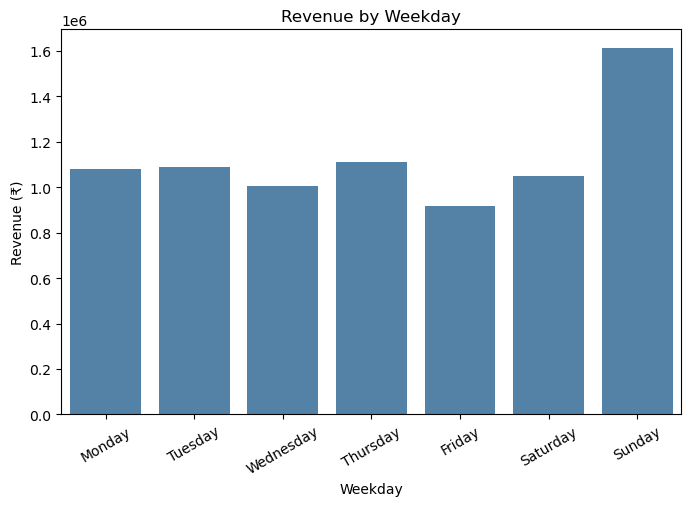

Peak sales day: Sunday


In [22]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_map = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul'}

weekday_rev = df_sales.groupby('Weekday')['Total'].sum().reindex(day_order).reset_index()
weekday_rev.columns = ['Weekday', 'Revenue']

plt.figure(figsize=(8, 5))
sns.barplot(data=weekday_rev, x='Weekday', y='Revenue', color='steelblue')
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.show()

print(f"Peak sales day: {weekday_rev.loc[weekday_rev['Revenue'].idxmax(), 'Weekday']}")

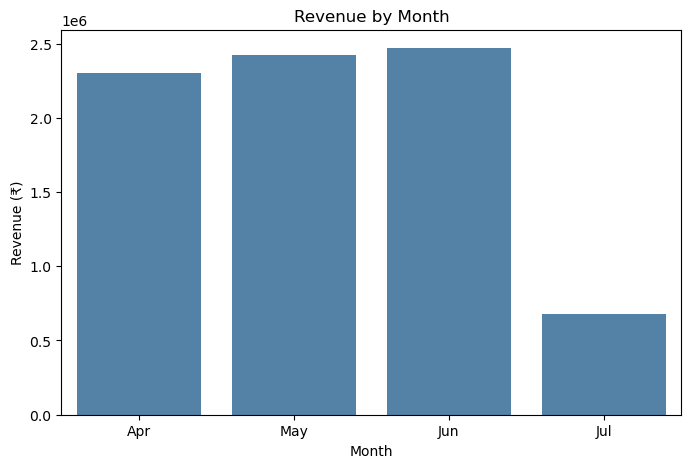

In [24]:
month_rev = df_sales.groupby('Month')['Total'].sum().reset_index()
month_rev['Month_name'] = month_rev['Month'].map(month_map)

plt.figure(figsize=(8, 5))
sns.barplot(data=month_rev, x='Month_name', y='Total', color='steelblue')
plt.title('Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.show()

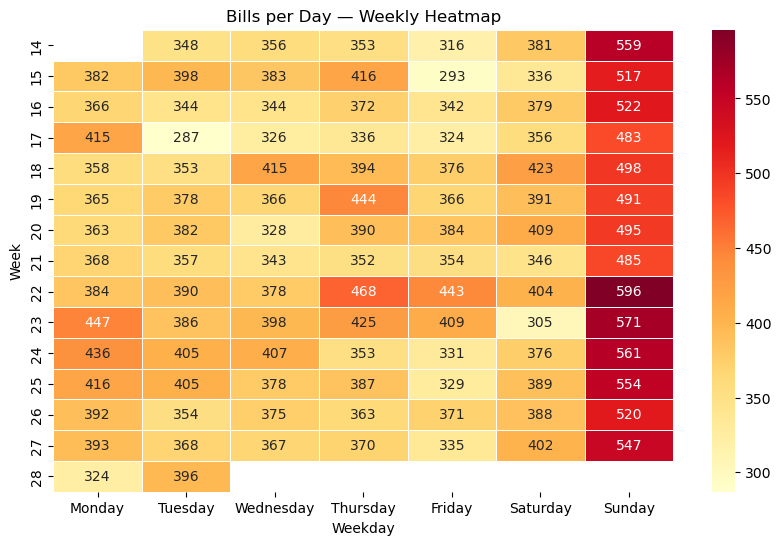

In [25]:
df_sales['Week'] = df_sales['Date'].dt.isocalendar().week.astype(int)
heatmap_data = df_sales.groupby(['Week','Weekday'])['Bill.NO'].nunique().unstack()
heatmap_data = heatmap_data.reindex(columns=day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Bills per Day — Weekly Heatmap')
plt.show()

# 5. Product Performance & Pareto Analysis

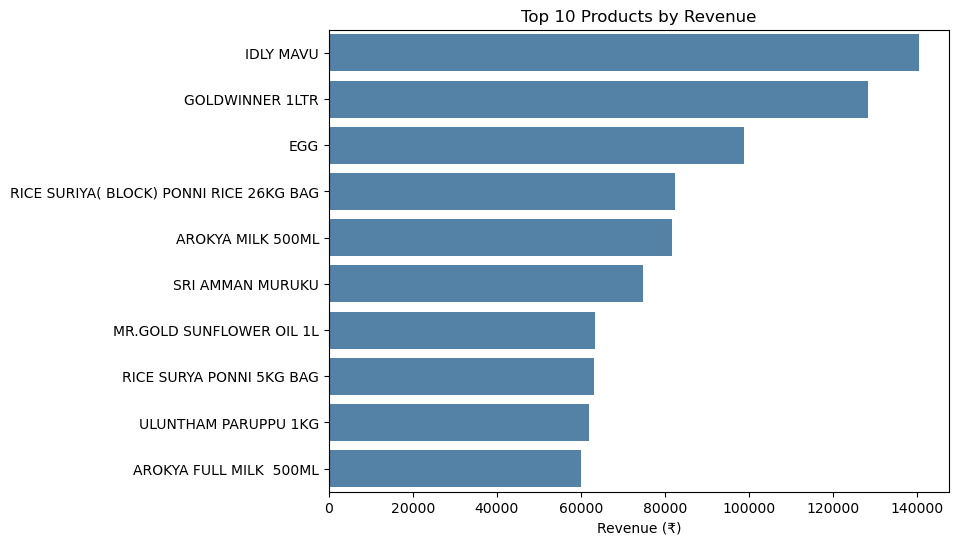

                           Product Name  Revenue  Units_sold  Transactions    Avg_rate
                              IDLY MAVU 140520.0      4684.0          3277   30.000000
                        GOLDWINNER 1LTR 128209.0       835.0           649  153.543143
                                    EGG  98796.8     16593.0          1800    5.961611
RICE SURIYA( BLOCK) PONNI RICE 26KG BAG  82350.0        48.0            40 1714.250000
                      AROKYA MILK 500ML  81607.0      2400.0          1624   34.003079
                       SRI AMMAN MURUKU  74810.0      1361.0          1105   54.959276
               MR.GOLD SUNFLOWER OIL 1L  63312.0       420.0           324  150.751543
               RICE SURYA PONNI 5KG BAG  63111.0       179.0           177  352.491525
                   ULUNTHAM PARUPPU 1KG  61985.0       487.0           394  127.185279
                AROKYA FULL MILK  500ML  60041.0      1561.0          1092   38.456960


In [26]:
product_perf = df_sales.groupby('Product Name').agg(
    Revenue=('Total', 'sum'),
    Units_sold=('Qty', 'sum'),
    Transactions=('Bill.NO', 'count'),
    Avg_rate=('Rate', 'mean')
).reset_index().sort_values('Revenue', ascending=False)

top10 = product_perf.head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=top10, y='Product Name', x='Revenue', color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (₹)')
plt.ylabel('')
plt.show()

print(top10[['Product Name','Revenue','Units_sold','Transactions','Avg_rate']].to_string(index=False))

In [27]:
product_perf_sorted = product_perf.sort_values('Revenue', ascending=False).reset_index(drop=True)
product_perf_sorted['Cumulative_%'] = (
    product_perf_sorted['Revenue'].cumsum() / product_perf_sorted['Revenue'].sum() * 100
)
p80 = product_perf_sorted[product_perf_sorted['Cumulative_%'] <= 80]

print(f"Total products     : {len(product_perf_sorted)}")
print(f"Products → 80% rev : {len(p80)} ({len(p80)/len(product_perf_sorted)*100:.1f}%)")

Total products     : 4610
Products → 80% rev : 998 (21.6%)


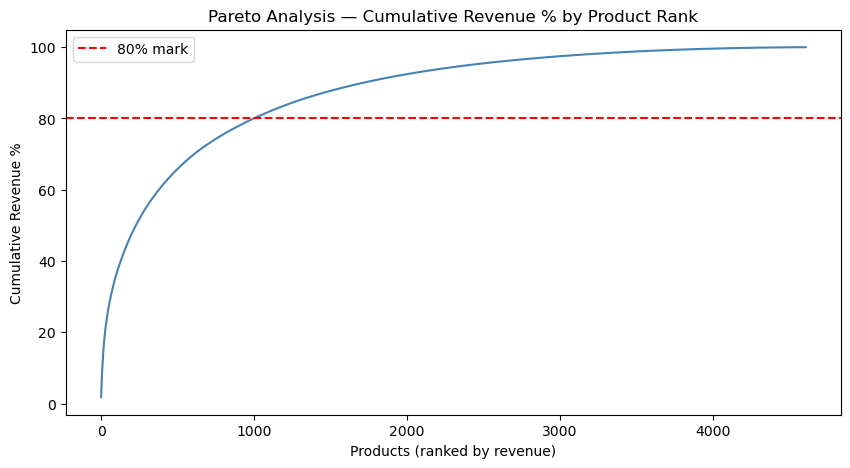

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(product_perf_sorted.index, product_perf_sorted['Cumulative_%'], color='steelblue')
plt.axhline(80, color='red', linestyle='--', label='80% mark')
plt.title('Pareto Analysis — Cumulative Revenue % by Product Rank')
plt.xlabel('Products (ranked by revenue)')
plt.ylabel('Cumulative Revenue %')
plt.legend()
plt.show()

# 6. Slow Movers and Price Segmentation


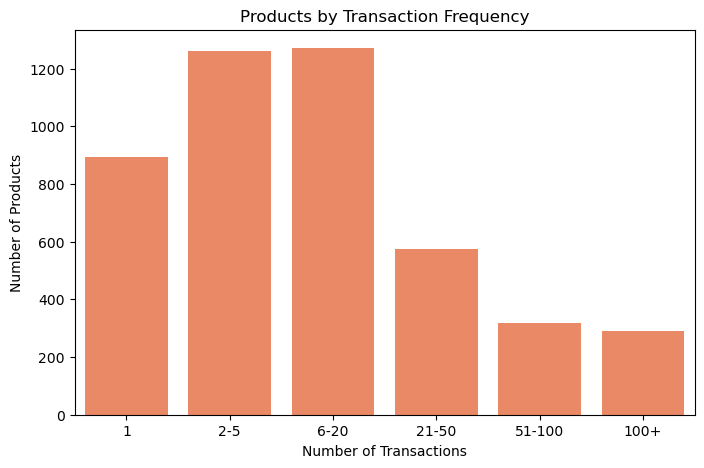

In [29]:
buckets = pd.cut(product_perf['Transactions'],
                  bins=[0,1,5,20,50,100,product_perf['Transactions'].max()],
                  labels=['1','2-5','6-20','21-50','51-100','100+'])
bucket_counts = buckets.value_counts().sort_index().reset_index()
bucket_counts.columns = ['Transaction_Range', 'Num_Products']

plt.figure(figsize=(8, 5))
sns.barplot(data=bucket_counts, x='Transaction_Range', y='Num_Products', color='coral')
plt.title('Products by Transaction Frequency')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Products')
plt.show()

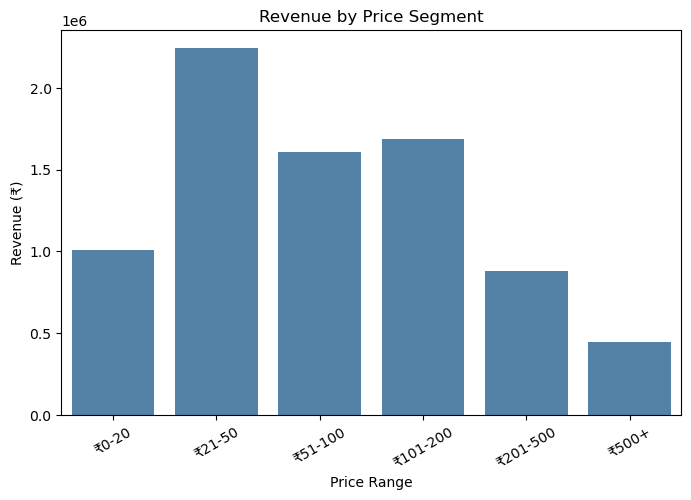

In [30]:
bins = [0,20,50,100,200,500,df_sales['Rate'].max()]
labels = ['₹0-20','₹21-50','₹51-100','₹101-200','₹201-500','₹500+']
df_sales['Price_segment'] = pd.cut(df_sales['Rate'], bins=bins, labels=labels)
seg_rev = df_sales.groupby('Price_segment', observed=True)['Total'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=seg_rev, x='Price_segment', y='Total', color='steelblue')
plt.title('Revenue by Price Segment')
plt.xlabel('Price Range')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)
plt.show()